In [17]:
import os
import json
import math
import numpy as np
import pandas as pd

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
# from IPython.display import set_matplotlib_formats
from matplotlib.colors import to_rgb
import matplotlib
# matplotlib.rcParams['lines.linewidth'] = 2.0
# import seaborn as sns

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
# Torchvision
import torchvision
from torchvision.datasets import FashionMNIST
from torchvision import transforms

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import random_split

In [18]:
device = torch.device("cuda:2") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.3184, 0.2927, 0.3013), (0.2763, 0.2655, 0.2686)),
])

dataset = ImageFolder("trafic_32", transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [20]:
for images, labels in train_loader:
    print(images.shape)  # [batch_size, 3, 32, 32]
    print(labels.shape)  # [batch_size]
    break

torch.Size([32, 3, 32, 32])
torch.Size([32])


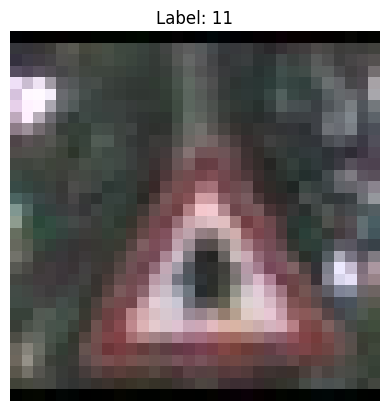

00011


In [ ]:
image, label = train_dataset[100]

# PyTorch tensor → HWC for plotting
img = image.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [ ]:
all_samples = torch.stack([sample[0] for sample in train_dataset])
print(f"Data norm: mean={all_samples.mean():.4f} | std={all_samples.std():.4f}")
print(f"Data norm per channel: mean={all_samples.mean(axis=(0,2,3))} | std={all_samples.std(axis=(0,2,3))}")

# Data norm: mean=0.3041 | std=0.2704
# Data norm per channel: mean=tensor([0.3184, 0.2927, 0.3013]) | std=tensor([0.2763, 0.2655, 0.2686])

Data norm: mean=0.3041 | std=0.2704
Data norm per channel: mean=tensor([0.3184, 0.2927, 0.3013]) | std=tensor([0.2763, 0.2655, 0.2686])
